# Recomputing the Köppen ram-pressure criterion for the MAUVE sample

**Date:** 2026-08-15  
**Scope:** all 40 physical galaxies in the current MAUVE master catalogue  
**Purpose:** a controlled reproduction of the Köppen et al. (2018) pressure diagnostic with updated, explicitly documented observational inputs.

This notebook answers a deliberately narrow question:

> Given the present H I deficit, what stripping pressure is required in the Köppen analytic disk model, and is that pressure larger than the maximum local pressure available at the galaxy's projected Virgo-centric radius?

The key diagnostic is

$$
\mathcal{R}_{\rm RP}=\frac{p_{\rm def}}{p_{\rm loc}},\qquad
\Delta_{\rm RP}=\log_{10}\mathcal{R}_{\rm RP}.
$$

Köppen et al. use a factor-of-two margin: $p_{\rm def}>2p_{\rm loc}$ is evidence that the observed deficit cannot be produced at the current projected position under the most favourable local velocity, and therefore favours **past stripping**. It is not a complete orbital reconstruction and it is not, by itself, a proof of a unique evolutionary history.

## 1. Revised roadmap and what is held fixed

This is **Level 1: controlled reproduction**.

1. Build one row per physical MAUVE galaxy. `NGC4567` and `NGC4568` remain separate; no combined `NGC4567_8` row is introduced.
2. Read observed $\log M_{\rm HI}$ and infall stage from the live local MAUVE master file.
3. Use a frozen 2026-08-15 HyperLeda snapshot for `logd25`, Hubble stage $T$, and rotation speed $v_{\rm rot}$.
4. Convert `logd25` to a physical optical diameter at the MAUVE distance, then define $R_{\rm opt}=D_{25}/2$.
5. Replace the historical expected-H I prescription with the Jones et al. (2018) AMIGA morphology-dependent relation and calculate
   $\mathrm{DEF}=\log M_{\rm HI,exp}-\log M_{\rm HI,obs}$.
6. Keep the Köppen H I profile, disk restoring-force approximation, Virgo ICM beta model, and Virgo dark-matter beta model unchanged.
7. Preserve the continuous pressure ratio and propagate uncertainties with Monte Carlo draws.
8. Compare the result across the MAUVE pre-/close-/post-peak labels without imposing an expected ordering.

### Important scope boundary

The configuration-space proxy $p_{\rm cfg}$ is a useful later extension, but it is not needed to recompute the core $p_{\rm def}/p_{\rm loc}$ criterion and is intentionally not mixed into this first-pass result.

## 2. Provenance ledger

| Quantity | Adopted source in this notebook | Role / caveat |
|---|---|---|
| MAUVE membership, $\log M_{\rm HI,obs}$, stage | local `mauve_master_wiki_newclass.fits` | The FITS table is the live MAUVE compilation. It does **not** encode a per-row literature reference or uncertainty for H I mass, so this notebook does not claim that all values originate from one survey. |
| `logd25`, `e_logd25`, $T$, $e_T$, $v_{\rm rot}$, formal error | HyperLeda live query, frozen on 2026-08-15 | Embedded below for reproducibility. HyperLeda defines `logd25` as $\log_{10}(D_{25}/0.1\,\mathrm{arcmin})$. |
| Expected H I mass | Jones et al. (2018), AMIGA | Morphology-dependent fit is fiducial; the all-type fit is retained as a sensitivity check. Intrinsic scatter is propagated. |
| Sky coordinates | local `simbad_object_crosswalk.csv` beside this notebook | Frozen SIMBAD cross-match used only for projected separation from M87. |
| Galaxy identity colours | local `MAUVE_galaxy_colors.dat` | Fixed project palette; black is not used for individual galaxies. |
| Virgo/Köppen physics | Köppen et al. (2018) | Held fixed in the controlled reproduction. |

Primary references:

- [Köppen et al. 2018, MNRAS 479, 4367](https://academic.oup.com/mnras/article/479/4/4367/5040236)
- [Jones et al. 2018, A&A 609, A17](https://www.aanda.org/articles/aa/full_html/2018/01/aa31448-17/aa31448-17.html)
- [HyperLeda query documentation](https://queryhyperleda.readthedocs.io/en/latest/examples.html)

The adopted common distance is 16.5 Mpc, consistent with the current MAUVE environmental workflow. It is held fixed rather than sampled because the master H I masses have not been supplied with enough provenance to rescale every row self-consistently with a distance draw.

In [1]:
# Core scientific and display dependencies.
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

# Reproducibility controls and fixed project choices.
RNG_SEED = 20260815
N_MC = 20_000
DISTANCE_MPC = 16.5
SIGMA_LOG_MHI_OBS_DEX = 0.10
VROT_FRACTIONAL_FALLBACK = 0.01
SIGMA_LOG_PLOC_DEX = np.log10(2.0)

# Köppen et al. disk parameters.
RHI_MAX_OVER_ROPT = 1.5
RESTORING_G = 2.0
STELLAR_BOOST_A = 15.0
R0_AT_ROPT_15_KPC = 2.0  # kpc

# Köppen et al. Virgo ICM and dark-matter beta models.
ICM_N0_CM3 = 0.04
ICM_RC_KPC = 13.4
ICM_BETA = 0.47
DM_RHO0_MSUN_PC3 = 3.8e-4
DM_RC_KPC = 320.0
DM_BETA = 1.0
G_KPC_KMS2_MSUN = 4.30091e-6

# One solar mass of atomic hydrogen spread over one square parsec gives this
# H-atom column; dividing by one kpc converts column/radius to number density.
MSUN_PC2_TO_H_CM2 = 1.2480e20
KPC_TO_CM = 3.0856775814913673e21
SURFACE_OVER_KPC_TO_CM3 = MSUN_PC2_TO_H_CM2 / KPC_TO_CM

HERE = Path.cwd()
MASTER_PATH = HERE / "mauve_master_wiki_newclass.fits"
COLOR_PATH = HERE / "MAUVE_galaxy_colors.dat"
COORD_PATH = HERE / "simbad_object_crosswalk.csv"

print(f"Working directory: {HERE}")
print(f"Monte Carlo draws per galaxy: {N_MC:,}")

Working directory: /Users/Igniz/Desktop/ICRAR/further
Monte Carlo draws per galaxy: 20,000


## 3. Assemble the 40-galaxy analysis table

The joins below are intentionally strict. A missing galaxy, duplicate identifier, or accidental combined-pair name should stop the notebook immediately rather than produce a partially matched result.

The fixed colour file is read independently of catalogue row order. This matters because plotting colours should continue to identify the same physical galaxy after sorting by stage, pressure, or deficiency.

In [2]:
def clean_text(value):
    """Decode byte strings from FITS tables and remove surrounding whitespace."""
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def read_mauve_colors(path):
    """Read the approved project colour mapping, ignoring its comment header."""
    colors = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                continue
            fields = line.split()
            colors[fields[1]] = fields[3]
    return colors


master = Table.read(MASTER_PATH).to_pandas()
master["Galaxy"] = master["Galaxy"].map(clean_text)
master["stage"] = master["class"].astype(int)
master["stage_label"] = master["stage"].map({1: "pre-peak", 2: "close-to-peak", 3: "post-peak"})

coords = pd.read_csv(COORD_PATH).rename(columns={"component": "Galaxy"})
coords["Galaxy"] = coords["Galaxy"].map(clean_text)

galaxy_colors = read_mauve_colors(COLOR_PATH)

assert len(master) == 40, f"Expected 40 physical MAUVE galaxies, found {len(master)}"
assert master["Galaxy"].is_unique, "The MAUVE master catalogue contains duplicate galaxy IDs"
assert "NGC4567_8" not in set(master["Galaxy"]), "Combined pair ID found in a component-level analysis"
assert set(master["Galaxy"]) == set(coords["Galaxy"]), "SIMBAD cross-match does not match the MAUVE sample"
assert set(master["Galaxy"]).issubset(galaxy_colors), "Fixed colours are missing for one or more galaxies"

sample = master.merge(
    coords[["Galaxy", "main_id", "ra_deg", "dec_deg", "coordinate_bibcode"]],
    on="Galaxy",
    how="left",
    validate="one_to_one",
)
sample["galaxy_color"] = sample["Galaxy"].map(galaxy_colors)

display(sample[["Galaxy", "logMHI", "stage_label", "main_id", "ra_deg", "dec_deg"]])
print("Strict sample assembly passed: 40 unique component galaxies.")

,Galaxy,logMHI,stage_label,main_id,ra_deg,dec_deg
0,NGC4189,8.78,pre-peak,NGC 4189,183.4,13.42
1,NGC4192,9.655,pre-peak,M 98,183.5,14.9
2,NGC4222,8.832,pre-peak,NGC 4222,184.1,13.31
3,NGC4254,9.673,pre-peak,M 99,184.7,14.42
4,NGC4294,9.24,pre-peak,NGC 4294,185.3,11.51
5,NGC4321,9.486,pre-peak,M 100,185.7,15.82
6,NGC4351,8.503,pre-peak,NGC 4351,186,12.21
7,NGC4383,9.492,pre-peak,NGC 4383,186.4,16.47
8,NGC4396,8.963,pre-peak,NGC 4396,186.5,15.67
9,NGC4535,9.542,pre-peak,NGC 4535,188.6,8.198


Strict sample assembly passed: 40 unique component galaxies.


## 4. Frozen HyperLeda input snapshot

The table below is embedded, rather than queried during execution, so the notebook remains reproducible if the live database changes or is temporarily unavailable.

- `logd25`: $\log_{10}$ of the apparent major-axis diameter in units of 0.1 arcmin.
- `T`: numerical Hubble stage used to choose the morphology-dependent AMIGA relation.
- `vrot`: reported HyperLeda homogenized maximum rotation velocity in km s$^{-1}$.
- `e_vrot`: literature/catalogue uncertainty on that reported velocity where available.

The Monte Carlo now follows one explicit rule:

$$
\sigma(v_{\rm rot})=
\begin{cases}
e(v_{\rm rot}), & e(v_{\rm rot})\ 	ext{is finite and positive},\\
0.01v_{\rm rot}, & \text{otherwise}.
\end{cases}
$$

Thus the 1% value is only a fallback for missing literature uncertainty; it is not a floor applied to every galaxy.

In [3]:
HYPERLEDA_CSV = """Galaxy,logd25,e_logd25,t,e_t,vrot,e_vrot,hl_type
NGC4189,1.34,0.03,5.9,0.9,195.9,4.7,Sc
NGC4192,2.04,0.02,2.6,0.8,216.0,,SABb
NGC4222,1.45,0.03,6.6,1.1,99.8,,Scd
NGC4254,1.70,0.03,5.2,0.7,299.5,8.8,Sc
NGC4294,1.43,0.03,5.9,0.5,94.9,2.1,SBc
NGC4321,1.78,0.02,4.0,0.3,278.6,6.2,SABb
NGC4351,1.20,0.04,2.8,1.7,67.2,1.9,SBb
NGC4383,1.22,0.07,0.8,0.8,103.3,2.5,Sa
NGC4396,1.47,0.04,6.8,0.8,89.0,2.2,Scd
NGC4535,1.91,0.02,5.0,0.4,304.3,6.8,Sc
NGC4567,1.44,0.02,4.0,0.3,224.4,5.3,Sbc
NGC4568,1.63,0.03,4.1,0.3,165.5,7.8,Sbc
NGC4298,1.40,0.05,5.1,0.6,190.2,5.2,Sc
NGC4302,1.78,0.03,5.3,0.8,167.8,,Sc
NGC4330,1.36,0.03,6.1,0.6,114.4,3.4,Sc
NGC4388,1.73,0.02,2.8,0.7,171.1,,SBb
NGC4402,1.55,0.02,3.2,0.8,114.4,2.8,Sb
NGC4424,1.48,0.03,1.3,1.6,28.6,1.1,Sa
NGC4501,1.94,0.03,3.3,0.6,272.1,4.4,Sb
NGC4522,1.54,0.02,5.9,0.6,96.3,2.5,Sc
NGC4654,1.67,0.02,5.9,0.5,149.6,2.1,Sc
NGC4694,1.30,0.04,-1.8,0.7,50.3,1.6,S0
NGC4064,1.51,0.03,1.2,1.8,84.9,2.9,SBa
NGC4216,1.89,0.01,3.0,0.5,244.8,,SABb
NGC4293,1.79,0.03,0.3,0.8,125.9,4.4,S0-a
NGC4380,1.52,0.03,2.4,0.9,144.7,3.7,SABa
NGC4394,1.54,0.02,3.0,0.4,238.3,8.7,SBb
NGC4405,1.18,0.06,0.3,1.1,75.8,2.9,S0-a
NGC4419,1.59,0.04,1.2,0.9,100.4,2.6,Sa
NGC4450,1.74,0.02,2.4,0.7,184.7,4.6,Sab
IC3392,1.41,0.05,2.4,0.8,80.6,2.4,Sab
NGC4457,1.45,0.03,0.3,1.1,101.3,3.2,S0-a
NGC4548,1.74,0.03,3.1,0.5,177.6,4.8,Sb
NGC4569,1.96,0.02,2.4,0.7,185.8,5.4,Sab
NGC4579,1.70,0.02,2.8,0.6,249.5,7.3,Sb
NGC4580,1.27,0.03,1.6,0.7,104.7,3.2,SABa
NGC4606,1.39,0.04,0.6,1.4,70.2,2.2,SBa
NGC4607,1.46,0.03,4.0,2.2,99.1,,SBbc
NGC4689,1.58,0.03,4.7,0.9,120.5,2.4,Sc
NGC4698,1.58,0.02,1.6,1.0,203.0,3.2,Sab
"""

hyperleda = pd.read_csv(StringIO(HYPERLEDA_CSV))
assert len(hyperleda) == 40 and hyperleda["Galaxy"].is_unique
assert set(sample["Galaxy"]) == set(hyperleda["Galaxy"]), "HyperLeda snapshot/sample mismatch"

sample = sample.merge(hyperleda, on="Galaxy", how="left", validate="one_to_one")
has_literature_evrot = np.isfinite(sample["e_vrot"]) & (sample["e_vrot"] > 0)
sample["e_vrot_used"] = np.where(
    has_literature_evrot,
    sample["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * sample["vrot"],
)
sample["e_vrot_source"] = np.where(
    has_literature_evrot, "literature e_vrot", "1% of reported vrot",
)

assert sample[["logd25", "e_logd25", "t", "e_t", "vrot"]].notna().all().all()
display(sample[["Galaxy", "logd25", "e_logd25", "t", "e_t", "hl_type", "vrot", "e_vrot", "e_vrot_used", "e_vrot_source"]])
print("HyperLeda coverage: 40/40 for logd25, T, and vrot.")

,Galaxy,logd25,e_logd25,t,e_t,hl_type,vrot,e_vrot,e_vrot_used,e_vrot_source
0,NGC4189,1.34,0.03,5.9,0.9,Sc,195.9,4.7,4.7,literature e_vrot
1,NGC4192,2.04,0.02,2.6,0.8,SABb,216,NaN,2.16,1% of reported vrot
2,NGC4222,1.45,0.03,6.6,1.1,Scd,99.8,NaN,0.998,1% of reported vrot
3,NGC4254,1.7,0.03,5.2,0.7,Sc,299.5,8.8,8.8,literature e_vrot
4,NGC4294,1.43,0.03,5.9,0.5,SBc,94.9,2.1,2.1,literature e_vrot
5,NGC4321,1.78,0.02,4,0.3,SABb,278.6,6.2,6.2,literature e_vrot
6,NGC4351,1.2,0.04,2.8,1.7,SBb,67.2,1.9,1.9,literature e_vrot
7,NGC4383,1.22,0.07,0.8,0.8,Sa,103.3,2.5,2.5,literature e_vrot
8,NGC4396,1.47,0.04,6.8,0.8,Scd,89,2.2,2.2,literature e_vrot
9,NGC4535,1.91,0.02,5,0.4,Sc,304.3,6.8,6.8,literature e_vrot


HyperLeda coverage: 40/40 for logd25, T, and vrot.


## 5. Optical diameter and the AMIGA expected-H I calibration

HyperLeda's definition gives

$$
D_{25}[\mathrm{arcmin}]=0.1\,10^{\mathrm{logd25}}.
$$

At the fixed MAUVE distance, the angular diameter is converted to kpc and
$R_{\rm opt}=D_{25}/2$.

The fiducial Jones et al. (2018) relation is

$$
\log M_{\rm HI,exp}=A_T\,[2\log D_{25}(\mathrm{kpc})]+B_T,
$$

with $(A_T,B_T,\sigma_{\rm int})=(1.04,6.44,0.27)$ for $T<3$,
$(0.93,7.14,0.16)$ for $3\le T\le5$, and $(0.81,7.53,0.17)$ for $T>5$.

The all-type comparison relation is

$$
\log M_{\rm HI,exp,all}=1.72\log D_{25}(\mathrm{kpc})+7.30
$$

with 0.21 dex intrinsic scatter. The morphology-dependent value is the primary result; the all-type value is retained to expose sensitivity to calibration choice.

In [4]:
def angular_diameter_kpc(logd25, distance_mpc=DISTANCE_MPC):
    """Convert HyperLeda logd25 to physical D25 in kpc using the small-angle relation."""
    d25_arcmin = 0.1 * np.power(10.0, np.asarray(logd25))
    return np.deg2rad(d25_arcmin / 60.0) * distance_mpc * 1_000.0


def amiga_parameters(t_stage):
    """Return Jones+2018 morphology-dependent A, B, and intrinsic scatter."""
    t_stage = np.asarray(t_stage)
    a = np.select([t_stage < 3, t_stage <= 5], [1.04, 0.93], default=0.81)
    b = np.select([t_stage < 3, t_stage <= 5], [6.44, 7.14], default=7.53)
    scatter = np.select([t_stage < 3, t_stage <= 5], [0.27, 0.16], default=0.17)
    return a, b, scatter


sample["D25_arcmin"] = 0.1 * 10.0 ** sample["logd25"]
sample["D25_kpc"] = angular_diameter_kpc(sample["logd25"])
sample["Ropt_kpc"] = 0.5 * sample["D25_kpc"]

a_t, b_t, scatter_t = amiga_parameters(sample["t"])
sample["amiga_A"] = a_t
sample["amiga_B"] = b_t
sample["amiga_scatter_dex"] = scatter_t
sample["logMHI_exp"] = a_t * (2.0 * np.log10(sample["D25_kpc"])) + b_t
sample["logMHI_exp_all"] = 1.72 * np.log10(sample["D25_kpc"]) + 7.30
sample["DEF"] = sample["logMHI_exp"] - sample["logMHI"]
sample["DEF_all"] = sample["logMHI_exp_all"] - sample["logMHI"]
sample["amiga_applicability_note"] = np.where(
    sample["t"] < 0,
    "T<0: early-type extrapolation; interpret cautiously",
    "within adopted T-bin implementation",
)

display(sample[[
    "Galaxy", "stage_label", "t", "D25_arcmin", "D25_kpc", "Ropt_kpc",
    "logMHI", "logMHI_exp", "DEF", "DEF_all", "amiga_scatter_dex",
    "amiga_applicability_note",
]])

,Galaxy,stage_label,t,D25_arcmin,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DEF_all,amiga_scatter_dex,amiga_applicability_note
0,NGC4189,pre-peak,5.9,2.188,10.5,5.25,8.78,9.184,0.4041,0.2762,0.17,within adopted T-bin implementation
1,NGC4192,pre-peak,2.6,10.96,52.63,26.31,9.655,10.02,0.3648,0.6051,0.27,within adopted T-bin implementation
2,NGC4222,pre-peak,6.6,2.818,13.53,6.764,8.832,9.363,0.5305,0.4136,0.17,within adopted T-bin implementation
3,NGC4254,pre-peak,5.2,5.012,24.06,12.03,9.673,9.768,0.09461,0.002731,0.17,within adopted T-bin implementation
4,NGC4294,pre-peak,5.9,2.692,12.92,6.459,9.24,9.33,0.09037,-0.02851,0.17,within adopted T-bin implementation
5,NGC4321,pre-peak,4,6.026,28.92,14.46,9.486,9.858,0.3721,0.3275,0.16,within adopted T-bin implementation
6,NGC4351,pre-peak,2.8,1.585,7.607,3.803,8.503,8.273,-0.2297,0.3131,0.27,within adopted T-bin implementation
7,NGC4383,pre-peak,0.8,1.66,7.965,3.983,9.492,8.315,-1.177,-0.6417,0.27,within adopted T-bin implementation
8,NGC4396,pre-peak,6.8,2.951,14.16,7.082,8.963,9.395,0.4322,0.3173,0.17,within adopted T-bin implementation
9,NGC4535,pre-peak,5,8.128,39.01,19.51,9.542,10.1,0.5574,0.4946,0.16,within adopted T-bin implementation


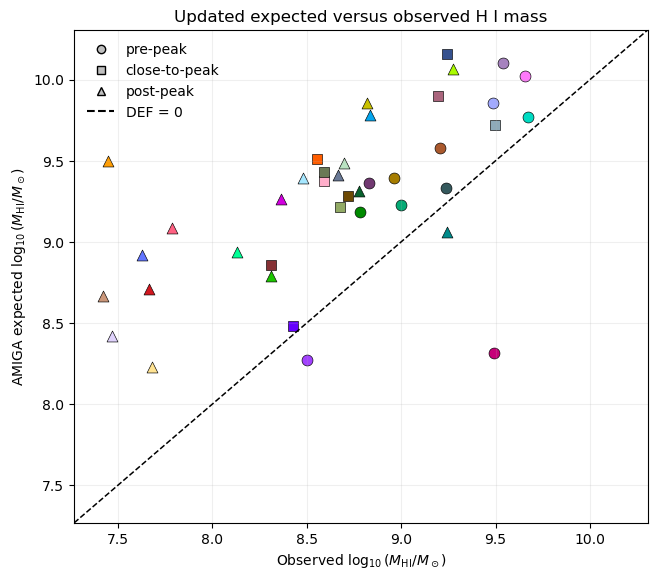

Central-input negative DEF galaxies (3): NGC4383, NGC4351, NGC4698


,Galaxy,stage_label,logMHI,logMHI_exp,DEF
7,NGC4383,pre-peak,9.492,8.315,-1.177
6,NGC4351,pre-peak,8.503,8.273,-0.2297
39,NGC4698,post-peak,9.241,9.063,-0.1776


In [5]:
# First diagnostic: where the updated expected masses sit relative to the observed compilation.
stage_markers = {1: "o", 2: "s", 3: "^"}
stage_labels = {1: "pre-peak", 2: "close-to-peak", 3: "post-peak"}

fig, ax = plt.subplots(figsize=(7.4, 6.4))
for _, row in sample.iterrows():
    ax.scatter(
        row["logMHI"], row["logMHI_exp"],
        marker=stage_markers[row["stage"]], s=62,
        color=row["galaxy_color"], edgecolor="black", linewidth=0.45,
    )

limits = [min(sample["logMHI"].min(), sample["logMHI_exp"].min()) - 0.15,
          max(sample["logMHI"].max(), sample["logMHI_exp"].max()) + 0.15]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1.1, label="DEF = 0")
ax.set(xlim=limits, ylim=limits,
       xlabel=r"Observed $\log_{10}(M_{\rm HI}/M_\odot)$",
       ylabel=r"AMIGA expected $\log_{10}(M_{\rm HI}/M_\odot)$")
ax.grid(alpha=0.2)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles.append(Line2D([], [], color="black", linestyle="--", label="DEF = 0"))
ax.legend(handles=handles, frameon=False)
ax.set_title("Updated expected versus observed H I mass")
plt.show()

# Report the central-input negative deficiencies explicitly. These are not
# forced to DEF=0 and will not receive a deterministic stripping inversion.
negative_deficiency = sample.loc[
    sample["DEF"] < 0,
    ["Galaxy", "stage_label", "logMHI", "logMHI_exp", "DEF"],
].sort_values("DEF")
print(
    f"Central-input negative DEF galaxies ({len(negative_deficiency)}): "
    + ", ".join(negative_deficiency["Galaxy"])
)
display(negative_deficiency)

## 6. Invert H I deficiency to a stripping radius

Köppen et al. adopt an initial H I surface-density profile

$$
\Sigma_{\rm HI}(r)=\frac{\Sigma_0}{[1+(r/R)^2]^{3/2}},
\quad R=R_{\rm opt},\quad r_{\max}=1.5R.
$$

Normalizing the profile to the expected initial H I mass $M_0$ gives

$$
\Sigma_0=\frac{M_0}{2\pi R^2 C},\qquad
C=1-\frac{1}{\sqrt{1+1.5^2}}.
$$

If all gas outside $r_{\rm strip}$ is removed, the remaining mass fraction is
$10^{-\mathrm{DEF}}$. Analytic inversion gives

$$
A=1-C10^{-\mathrm{DEF}},\qquad
r_{\rm strip}=R\sqrt{A^{-2}-1}.
$$

For $\mathrm{DEF}\le0$, this stripping interpretation has no physical missing-H I mass to invert. Those cases are retained in the results but assigned `NaN` for $r_{\rm strip}$ and $p_{\rm def}$; they are never clipped to zero deficiency.

In [6]:
PROFILE_C = 1.0 - 1.0 / np.sqrt(1.0 + RHI_MAX_OVER_ROPT**2)


def stripping_radius_kpc(deficiency, ropt_kpc):
    """Analytic Köppen radius enclosing 10**(-DEF) of the initial H I mass."""
    deficiency, ropt_kpc = np.broadcast_arrays(
        np.asarray(deficiency, dtype=float), np.asarray(ropt_kpc, dtype=float)
    )
    result = np.full(deficiency.shape, np.nan, dtype=float)
    valid = (deficiency > 0.0) & (ropt_kpc > 0.0)
    a_term = 1.0 - PROFILE_C * np.power(10.0, -deficiency[valid])
    result[valid] = ropt_kpc[valid] * np.sqrt(np.power(a_term, -2.0) - 1.0)
    return result


def sigma_hi_msun_pc2(r_kpc, ropt_kpc, log_mhi_initial):
    """Initial-profile H I surface density evaluated at radius r."""
    mhi_initial = np.power(10.0, np.asarray(log_mhi_initial, dtype=float))
    sigma0 = mhi_initial / (2.0 * np.pi * (np.asarray(ropt_kpc) * 1_000.0)**2 * PROFILE_C)
    return sigma0 / np.power(1.0 + (np.asarray(r_kpc) / np.asarray(ropt_kpc))**2, 1.5)


def required_pressure(deficiency, ropt_kpc, log_mhi_initial, vrot_kms):
    """Köppen p_def in units of 10^3 cm^-3 (km/s)^2."""
    r_strip = stripping_radius_kpc(deficiency, ropt_kpc)
    sigma_at_strip = sigma_hi_msun_pc2(r_strip, ropt_kpc, log_mhi_initial)
    r0_kpc = R0_AT_ROPT_15_KPC * np.asarray(ropt_kpc) / 15.0
    stellar_boost = 1.0 + STELLAR_BOOST_A * np.exp(-r_strip / r0_kpc)
    p_native = (
        sigma_at_strip
        * np.asarray(vrot_kms)**2
        / (RESTORING_G * r_strip)
        * stellar_boost
        * SURFACE_OVER_KPC_TO_CM3
    )
    return p_native / 1_000.0


# Limiting checks: DEF -> 0+ returns the original 1.5 R edge, and increasing
# deficiency moves the inferred stripping radius monotonically inward.
test_def = np.array([1e-8, 0.1, 0.5, 1.0, 2.0])
test_r = stripping_radius_kpc(test_def, np.ones_like(test_def))
assert np.isclose(test_r[0], RHI_MAX_OVER_ROPT, rtol=1e-6)
assert np.all(np.diff(test_r) < 0)
assert np.isnan(stripping_radius_kpc(np.array([-0.1, 0.0]), 1.0)).all()
print("Analytic inversion checks passed.")

Analytic inversion checks passed.


## 7. Maximum local pressure at projected Virgo-centric radius

For the original Köppen comparison, the ICM number-density profile is

$$
n_{\rm ICM}(R)=0.04\left[1+\left(\frac{R}{13.4\,\mathrm{kpc}}\right)^2\right]^{-3(0.47)/2}
\ \mathrm{cm}^{-3}.
$$

The Virgo dark-matter density is a beta model with $\beta_{\rm DM}=1$:

$$
\rho_{\rm DM}(r)=\rho_0[1+(r/R_c)^2]^{-3/2},
$$

where $\rho_0=3.8\times10^{-4}\,M_\odot\,\mathrm{pc}^{-3}$ and $R_c=320$ kpc.
For this special beta value, integrating the spherical potential to infinity gives

$$
v_{\rm esc}^2(r)=8\pi G\rho_0R_c^2\frac{\operatorname{asinh}(r/R_c)}{r/R_c}.
$$

The deliberately optimistic local upper limit is

$$
p_{\rm loc}=n_{\rm ICM}(R_{\rm proj})v_{\rm esc}^2(R_{\rm proj}).
$$

Using projected distance and the escape speed makes this an upper limit under the adopted spherical model. Köppen et al. estimate that $p_{\rm loc}$ is uncertain by roughly a factor of two; that uncertainty is included below.

In [7]:
M87 = SkyCoord("12h30m49.42338s", "+12d23m28.0439s", frame="icrs")


def escape_speed_squared_kms2(radius_kpc):
    """Analytic escape-speed squared for the Köppen beta_DM=1 halo."""
    radius_kpc = np.asarray(radius_kpc, dtype=float)
    x = radius_kpc / DM_RC_KPC
    shape = np.ones_like(x)
    nonzero = x != 0
    shape[nonzero] = np.arcsinh(x[nonzero]) / x[nonzero]
    rho0_msun_kpc3 = DM_RHO0_MSUN_PC3 * 1.0e9
    return 8.0 * np.pi * G_KPC_KMS2_MSUN * rho0_msun_kpc3 * DM_RC_KPC**2 * shape


def local_pressure(radius_mpc):
    """Köppen p_loc in units of 10^3 cm^-3 (km/s)^2."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    n_icm = ICM_N0_CM3 * np.power(1.0 + (radius_kpc / ICM_RC_KPC)**2, -1.5 * ICM_BETA)
    return n_icm * escape_speed_squared_kms2(radius_kpc) / 1_000.0


galaxy_sky = SkyCoord(sample["ra_deg"].to_numpy() * u.deg, sample["dec_deg"].to_numpy() * u.deg)
sample["m87_separation_deg"] = galaxy_sky.separation(M87).degree
sample["Rproj_mpc"] = np.deg2rad(sample["m87_separation_deg"]) * DISTANCE_MPC
sample["p_loc"] = local_pressure(sample["Rproj_mpc"])

# Compact values transcribed from the paper's appendix. These test the model
# implementation independently of the updated MAUVE coordinates and distance.
PAPER_PLOC_CSV = """Galaxy,Rproj_mpc_paper,p_loc_paper
NGC4438,0.29,1.95
NGC4330,0.63,0.52
NGC4388,0.37,1.27
NGC4522,0.98,0.22
NGC4402,0.40,1.13
NGC4321,1.17,0.16
NGC4298,0.94,0.24
NGC4192,1.43,0.10
NGC4606,3.03,0.02
NGC4450,3.40,0.02
NGC4698,1.73,0.07
"""
paper_ploc = pd.read_csv(StringIO(PAPER_PLOC_CSV))
paper_ploc["p_loc_recomputed"] = local_pressure(paper_ploc["Rproj_mpc_paper"])
paper_ploc["fractional_residual"] = (
    paper_ploc["p_loc_recomputed"] - paper_ploc["p_loc_paper"]
) / paper_ploc["p_loc_paper"]

assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10
assert np.max(np.abs(paper_ploc["fractional_residual"])) < 0.30
display(paper_ploc)
print("Published p_loc regression passed; small residuals are consistent with rounded appendix values.")

,Galaxy,Rproj_mpc_paper,p_loc_paper,p_loc_recomputed,fractional_residual
0,NGC4438,0.29,1.95,1.975,0.01299
1,NGC4330,0.63,0.52,0.5358,0.0303
2,NGC4388,0.37,1.27,1.334,0.05038
3,NGC4522,0.98,0.22,0.2375,0.07976
4,NGC4402,0.4,1.13,1.173,0.03781
5,NGC4321,1.17,0.16,0.1693,0.05813
6,NGC4298,0.94,0.24,0.257,0.0708
7,NGC4192,1.43,0.1,0.1145,0.1451
8,NGC4606,3.03,0.02,0.02506,0.2529
9,NGC4450,3.4,0.02,0.01972,-0.01388


Published p_loc regression passed; small residuals are consistent with rounded appendix values.


## 8. Deterministic recomputation

The deterministic calculation uses the central value of every input. It is useful for auditing equations, but it should not be treated as the final classification because the AMIGA relation has intrinsic scatter and $p_{\rm loc}$ alone is uncertain by about a factor of two.

The pressure unit used by the paper and throughout the remaining notebook is
$10^3\,\mathrm{cm}^{-3}(\mathrm{km}\,\mathrm{s}^{-1})^2$.

In [8]:
sample["r_strip_kpc"] = stripping_radius_kpc(sample["DEF"], sample["Ropt_kpc"])
sample["p_def"] = required_pressure(
    sample["DEF"], sample["Ropt_kpc"], sample["logMHI_exp"], sample["vrot"]
)
sample["pressure_ratio"] = sample["p_def"] / sample["p_loc"]
sample["Delta_RP"] = np.log10(sample["pressure_ratio"])
sample["deterministic_status"] = np.select(
    [sample["DEF"] <= 0, sample["pressure_ratio"] > 2.0],
    ["non-positive DEF: no inversion", "past-stripping favoured"],
    default="locally attainable / ongoing-compatible",
)

deterministic_columns = [
    "Galaxy", "stage_label", "D25_kpc", "Ropt_kpc", "logMHI", "logMHI_exp",
    "DEF", "r_strip_kpc", "vrot", "Rproj_mpc", "p_def", "p_loc",
    "pressure_ratio", "Delta_RP", "deterministic_status",
]
display(sample[deterministic_columns])

,Galaxy,stage_label,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,r_strip_kpc,vrot,Rproj_mpc,p_def,p_loc,pressure_ratio,Delta_RP,deterministic_status
0,NGC4189,pre-peak,10.5,5.25,8.78,9.184,0.4041,3.605,195.9,1.232,2.599,0.1532,16.96,1.23,past-stripping favoured
1,NGC4192,pre-peak,52.63,26.31,9.655,10.02,0.3648,19.2,216,1.393,0.1488,0.1206,1.234,0.09121,locally attainable / ongoing-compatible
2,NGC4222,pre-peak,13.53,6.764,8.832,9.363,0.5305,3.856,99.8,1.048,0.7452,0.2092,3.563,0.5518,past-stripping favoured
3,NGC4254,pre-peak,24.06,12.03,9.673,9.768,0.09461,14.37,299.5,1.023,0.4839,0.2191,2.209,0.3442,past-stripping favoured
4,NGC4294,pre-peak,12.92,6.459,9.24,9.33,0.09037,7.789,94.9,0.7173,0.1116,0.424,0.2633,-0.5796,locally attainable / ongoing-compatible
5,NGC4321,pre-peak,28.92,14.46,9.486,9.858,0.3721,10.43,278.6,1.132,1.055,0.1805,5.846,0.7668,past-stripping favoured
6,NGC4351,pre-peak,7.607,3.803,8.503,8.273,-0.2297,NaN,67.2,0.4812,NaN,0.8585,NaN,NaN,non-positive DEF: no inversion
7,NGC4383,pre-peak,7.965,3.983,9.492,8.315,-1.177,NaN,103.3,1.233,NaN,0.1529,NaN,NaN,non-positive DEF: no inversion
8,NGC4396,pre-peak,14.16,7.082,8.963,9.395,0.4322,4.66,89,1.003,0.3928,0.2272,1.729,0.2378,locally attainable / ongoing-compatible
9,NGC4535,pre-peak,39.01,19.51,9.542,10.1,0.5574,10.71,304.3,1.233,1.732,0.153,11.32,1.054,past-stripping favoured


## 9. Monte Carlo uncertainty model

Each galaxy receives 20,000 independent draws. This is an uncertainty model, not a claim that every input error is perfectly Gaussian.

| Input | Sampling choice |
|---|---|
| `logd25` | Gaussian with the HyperLeda error |
| $T$ | Gaussian with the HyperLeda error; each draw can cross an AMIGA morphology boundary |
| AMIGA relation | Add the appropriate intrinsic scatter (0.27, 0.16, or 0.17 dex) after selecting the draw's $T$ bin |
| observed $\log M_{\rm HI}$ | Gaussian 0.10 dex provisional floor because the local master table has no row-level errors |
| $v_{\rm rot}$ | Gaussian with literature `e_vrot` when finite and positive; otherwise 1% of reported $v_{\rm rot}$ |
| $p_{\rm loc}$ | log-normal, $\sigma_{\log_{10}p}=\log_{10}2$, representing the stated factor-of-two model uncertainty |

The distance and sky position are held fixed for consistency with the supplied H I masses.

Two probabilities are reported:

- `P_DEF_positive`: fraction of all draws where the deficiency has a physical stripping inversion.
- `P_past_given_DEF_positive`: among those valid draws, the probability that $p_{\rm def}>2p_{\rm loc}$.

`P_past_joint` is also retained and equals the fraction of *all* draws satisfying both conditions. Keeping both quantities avoids disguising a galaxy whose pressure ratio looks decisive only in the small subset of draws with positive deficiency.

In [9]:
ratio_draws = {}


def q16_50_84(values):
    values = np.asarray(values)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(np.percentile(finite, [16, 50, 84]))


def monte_carlo_row(row, rng, n_draws=N_MC):
    """Propagate the stated uncertainty model for one galaxy."""
    logd25 = rng.normal(row.logd25, row.e_logd25, n_draws)
    t_draw = rng.normal(row.t, row.e_t, n_draws)
    a_draw, b_draw, intrinsic = amiga_parameters(t_draw)

    d25_kpc = angular_diameter_kpc(logd25)
    ropt_kpc = 0.5 * d25_kpc
    log_mhi_exp = (
        a_draw * (2.0 * np.log10(d25_kpc))
        + b_draw
        + rng.normal(0.0, intrinsic, n_draws)
    )
    log_mhi_obs = rng.normal(row.logMHI, SIGMA_LOG_MHI_OBS_DEX, n_draws)
    deficiency = log_mhi_exp - log_mhi_obs

    vrot = rng.normal(row.vrot, row.e_vrot_used, n_draws)
    vrot = np.clip(vrot, 1.0, None)
    p_def = required_pressure(deficiency, ropt_kpc, log_mhi_exp, vrot)
    p_loc = row.p_loc * np.power(10.0, rng.normal(0.0, SIGMA_LOG_PLOC_DEX, n_draws))

    valid = np.isfinite(p_def) & (deficiency > 0.0)
    ratio = np.where(valid, p_def / p_loc, np.nan)
    ratio_draws[row.Galaxy] = ratio[np.isfinite(ratio)]
    past = valid & (ratio > 2.0)
    d_q = q16_50_84(deficiency)
    r_q = q16_50_84(ratio)
    delta_q = q16_50_84(np.log10(ratio))
    pdef_q = q16_50_84(np.where(valid, p_def, np.nan))

    return {
        "DEF_p16": d_q[0], "DEF_p50": d_q[1], "DEF_p84": d_q[2],
        "ratio_p16": r_q[0], "ratio_p50": r_q[1], "ratio_p84": r_q[2],
        "Delta_RP_p16": delta_q[0], "Delta_RP_p50": delta_q[1], "Delta_RP_p84": delta_q[2],
        "p_def_p16": pdef_q[0], "p_def_p50": pdef_q[1], "p_def_p84": pdef_q[2],
        "P_DEF_positive": valid.mean(),
        "P_past_joint": past.mean(),
        "P_past_given_DEF_positive": past.sum() / valid.sum() if valid.any() else np.nan,
    }


rng = np.random.default_rng(RNG_SEED)
mc = pd.DataFrame([monte_carlo_row(row, rng) for row in sample.itertuples(index=False)])
results = pd.concat([sample.reset_index(drop=True), mc], axis=1)

def mc_interpretation(row):
    if row.P_DEF_positive < 0.5:
        return "mostly non-deficient / inversion unstable"
    if row.P_past_given_DEF_positive >= 0.84:
        return "past-stripping favoured"
    if row.P_past_given_DEF_positive <= 0.16:
        return "ongoing-compatible"
    return "ambiguous"


results["MC_interpretation"] = results.apply(mc_interpretation, axis=1)

mc_columns = [
    "Galaxy", "stage_label", "DEF_p16", "DEF_p50", "DEF_p84",
    "P_DEF_positive", "ratio_p16", "ratio_p50", "ratio_p84",
    "Delta_RP_p50", "P_past_joint", "P_past_given_DEF_positive", "MC_interpretation",
]
display(results[mc_columns])

,Galaxy,stage_label,DEF_p16,DEF_p50,DEF_p84,P_DEF_positive,ratio_p16,ratio_p50,ratio_p84,Delta_RP_p50,P_past_joint,P_past_given_DEF_positive,MC_interpretation
0,NGC4189,pre-peak,0.1664,0.3786,0.5895,0.9626,4.106,15.27,55.99,1.184,0.9022,0.9372,past-stripping favoured
1,NGC4192,pre-peak,0.1511,0.4843,0.7707,0.9277,0.4791,2.942,14.78,0.4687,0.5417,0.584,ambiguous
2,NGC4222,pre-peak,0.3143,0.5217,0.7244,0.9931,0.936,3.422,11.97,0.5343,0.656,0.6605,ambiguous
3,NGC4254,pre-peak,-0.1314,0.07085,0.2722,0.6382,1.243,3.702,11.95,0.5684,0.453,0.7097,ambiguous
4,NGC4294,pre-peak,-0.1186,0.08544,0.2879,0.6623,0.161,0.491,1.622,-0.3089,0.08015,0.121,ongoing-compatible
5,NGC4321,pre-peak,0.1815,0.3742,0.5617,0.9737,1.768,5.982,19.97,0.7768,0.7934,0.8149,ambiguous
6,NGC4351,pre-peak,-0.3858,0.04649,0.4015,0.5409,0.05599,0.2273,0.9221,-0.6434,0.03245,0.06,ongoing-compatible
7,NGC4383,pre-peak,-1.495,-1.173,-0.8536,0.00025,1.282,1.526,2.543,0.1837,5e-05,0.2,mostly non-deficient / inversion unstable
8,NGC4396,pre-peak,0.22,0.43,0.6387,0.9812,0.4749,1.74,6.275,0.2406,0.4467,0.4553,ambiguous
9,NGC4535,pre-peak,0.3651,0.5608,0.7564,0.9979,3.324,11.47,39.8,1.06,0.915,0.9169,past-stripping favoured


### 9.1 Per-galaxy probability-density views of $p_{\rm def}/p_{\rm loc}$

The 40 panels below expose the full Monte Carlo shape instead of reducing each galaxy to one probability.

- Each histogram is normalized as a probability density and uses only draws with a physical positive-deficiency inversion.
- The solid line marks $p_{\rm def}/p_{\rm loc}=1$; the dotted line marks the Köppen factor-of-two boundary.
- The horizontal axis is logarithmic because the pressure ratio spans several orders of magnitude.
- `P(DEF>0)` states how often an inversion exists at all. `P(>2 | DEF>0)` measures the past-stripping probability conditional on those physical draws.

The conditional histogram must therefore be read together with `P(DEF>0)`. For example, a distribution based on only a tiny fraction of positive-DEF draws is not strong evidence even if those few draws lie beyond a reference line.

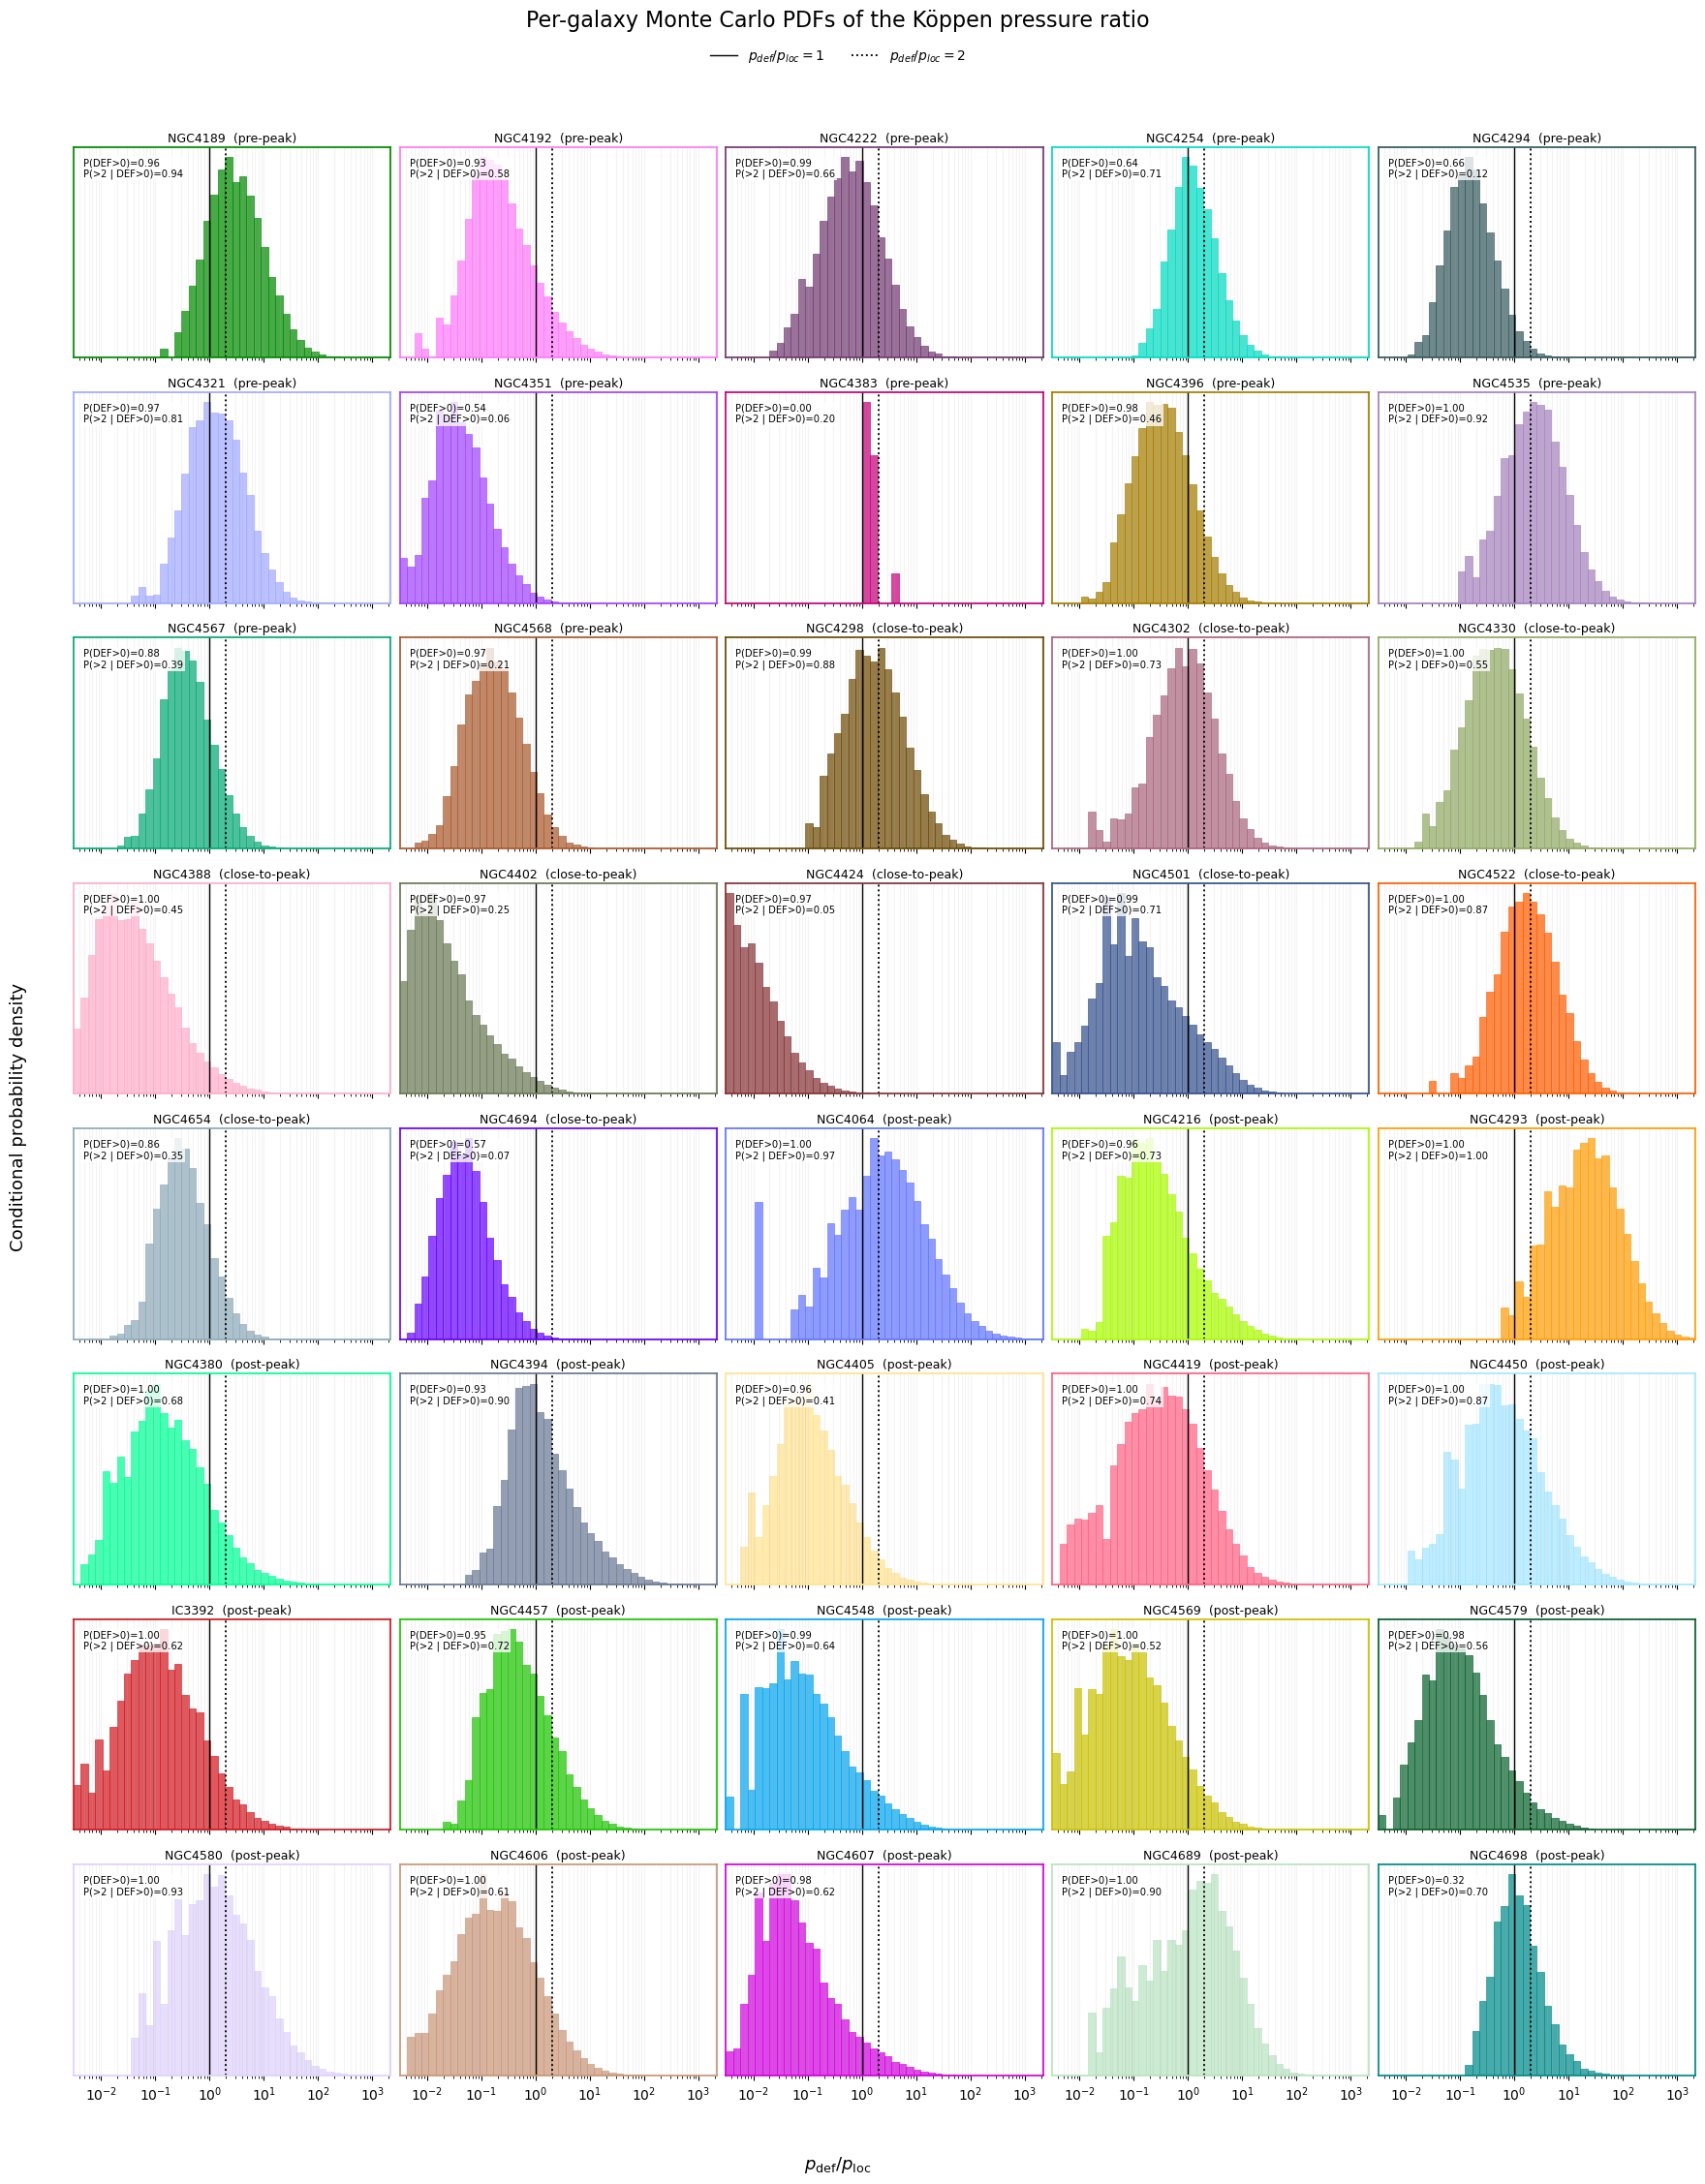

In [10]:
# Use common logarithmic bins so all 40 panels are directly comparable.
all_ratio_values = np.concatenate([values for values in ratio_draws.values() if len(values) > 0])
x_min = min(0.25, np.percentile(all_ratio_values, 0.1))
x_max = max(4.0, np.percentile(all_ratio_values, 99.9))
ratio_bins = np.geomspace(x_min, x_max, 45)

fig, axes = plt.subplots(8, 5, figsize=(18, 23), sharex=True)
axes = axes.ravel()

for ax, row in zip(axes, results.itertuples(index=False)):
    values = ratio_draws[row.Galaxy]
    if len(values) > 0:
        ax.hist(
            values,
            bins=ratio_bins,
            density=True,
            color=row.galaxy_color,
            alpha=0.72,
            edgecolor=row.galaxy_color,
            linewidth=0.6,
        )
    else:
        ax.text(0.5, 0.52, "No positive-DEF draws", transform=ax.transAxes,
                ha="center", va="center", fontsize=8)

    ax.axvline(1.0, color="black", linewidth=1.0)
    ax.axvline(2.0, color="black", linestyle=":", linewidth=1.35)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.grid(axis="x", which="both", alpha=0.15)
    ax.set_title(f"{row.Galaxy}  ({row.stage_label})", fontsize=9, pad=4)
    ax.text(
        0.03, 0.95,
        f"P(DEF>0)={row.P_DEF_positive:.2f}\n"
        f"P(>2 | DEF>0)={row.P_past_given_DEF_positive:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=7.2,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.2},
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(row.galaxy_color)
        spine.set_linewidth(1.25)

fig.supxlabel(r"$p_{\rm def}/p_{\rm loc}$", fontsize=13, y=0.025)
fig.supylabel("Conditional probability density", fontsize=13, x=0.025)
fig.suptitle(
    "Per-galaxy Monte Carlo PDFs of the Köppen pressure ratio",
    fontsize=16, y=0.997,
)
fig.legend(
    handles=[
        Line2D([], [], color="black", linewidth=1.0, label=r"$p_{def}/p_{loc}=1$"),
        Line2D([], [], color="black", linestyle=":", linewidth=1.35,
               label=r"$p_{def}/p_{loc}=2$"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0.035, 0.035, 1.0, 0.965), h_pad=1.1, w_pad=0.7)
plt.show()

## 10. Main pressure-plane result

The left panel shows deterministic central $p_{\rm def}$ against central $p_{\rm loc}$. The added right panel shows the corresponding **central** ratio $p_{\rm def}/p_{\rm loc}$ galaxy by galaxy; it contains no Monte Carlo summaries. The solid and dotted reference lines mark ratios 1 and 2.

Galaxies with non-positive central deficiency have no physical deficiency-inverted stripping radius. They are not plotted in either central-value panel and are named explicitly in the right-panel title and printed text.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


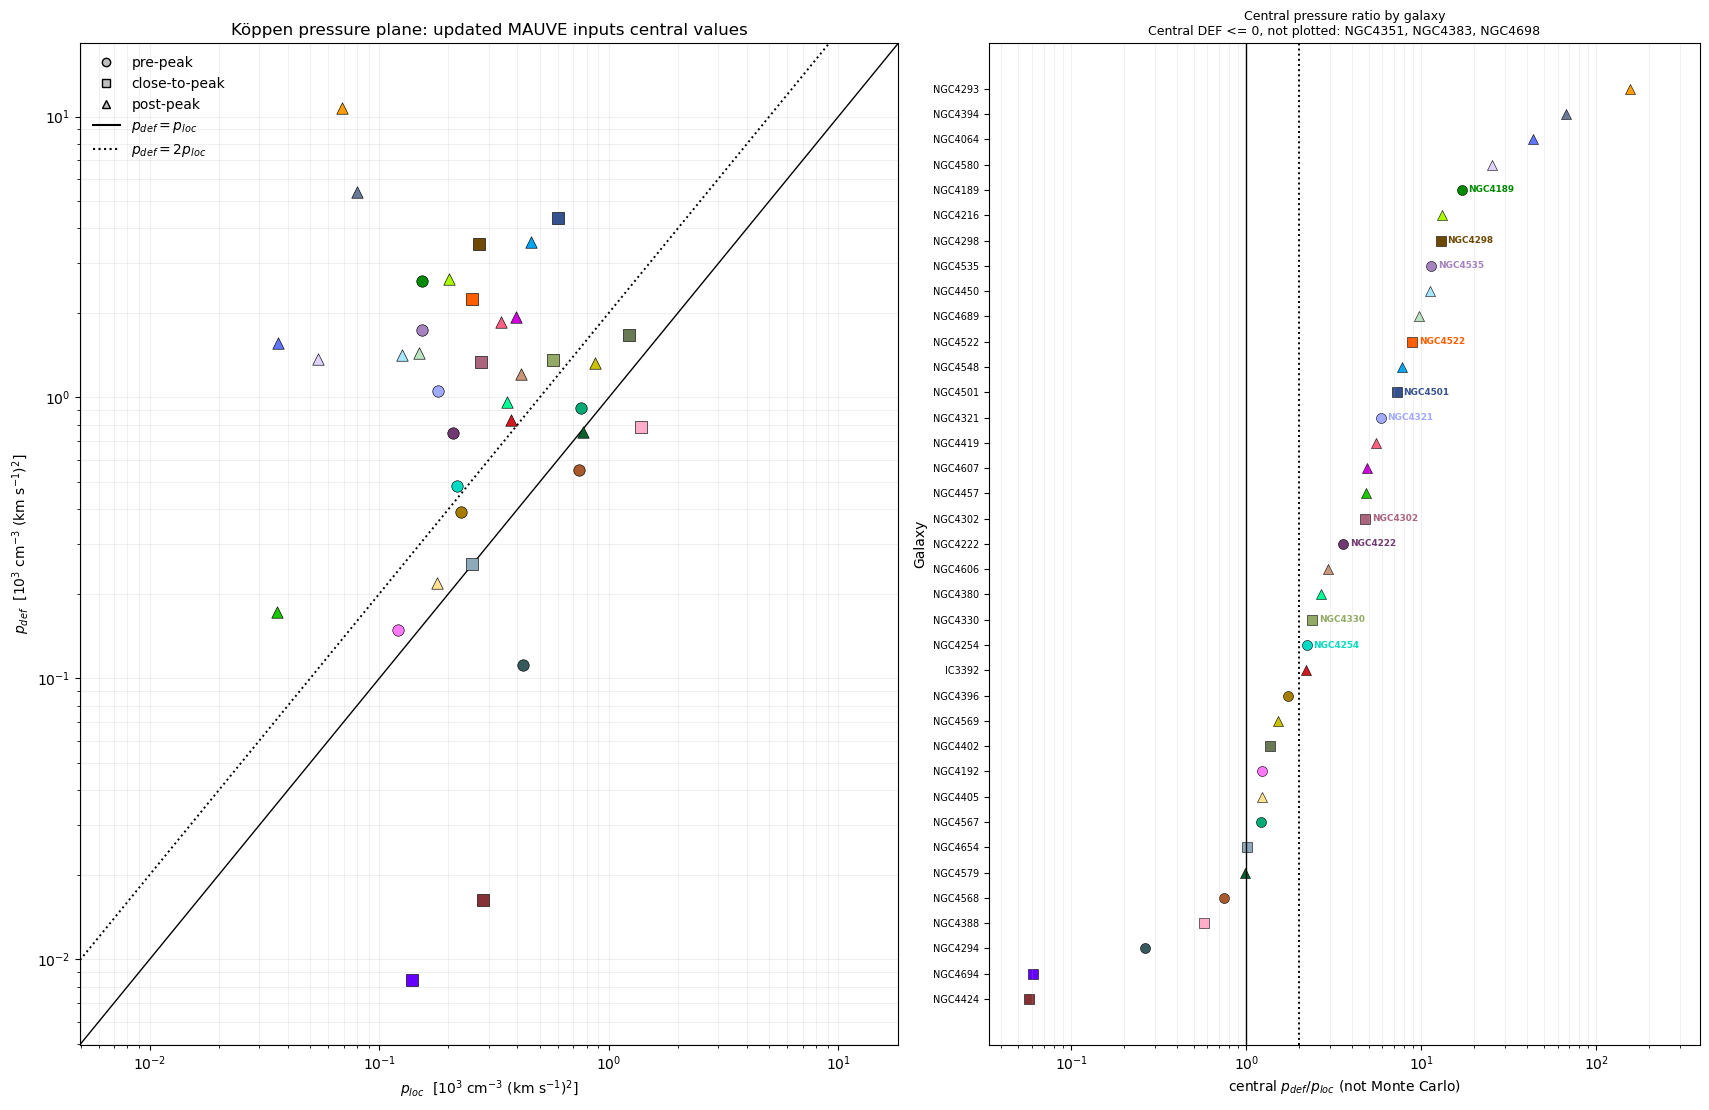

Central DEF <= 0 (not plotted in central-ratio panel): NGC4351, NGC4383, NGC4698
Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4222, NGC4254, NGC4321, NGC4535, NGC4298, NGC4302, NGC4330, NGC4501, NGC4522


In [11]:
fig, (ax_plane, ax_ratio) = plt.subplots(
    1, 2, figsize=(17.2, 11.2), gridspec_kw={"width_ratios": [1.15, 1.0]}
)
finite = np.isfinite(results["p_def"]) & np.isfinite(results["p_loc"])

for _, row in results.loc[finite].iterrows():
    ax_plane.scatter(
        row["p_loc"], row["p_def"], s=68,
        marker=stage_markers[row["stage"]], color=row["galaxy_color"],
        edgecolor="black", linewidth=0.45, zorder=3,
    )

lo = min(results.loc[finite, ["p_loc", "p_def"]].min()) / 1.7
hi = max(results.loc[finite, ["p_loc", "p_def"]].max()) * 1.7
grid = np.geomspace(lo, hi, 300)
ax_plane.plot(grid, grid, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_plane.plot(grid, 2.0 * grid, color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_plane.set_xscale("log")
ax_plane.set_yscale("log")
ax_plane.set(xlim=(lo, hi), ylim=(lo, hi),
             xlabel=r"$p_{loc}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]",
             ylabel=r"$p_{def}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]")
ax_plane.grid(which="both", alpha=0.18)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles += [Line2D([], [], color="black", label=r"$p_{def}=p_{loc}$"),
            Line2D([], [], color="black", linestyle=":", label=r"$p_{def}=2p_{loc}$")]
ax_plane.legend(handles=handles, frameon=False, loc="upper left")
ax_plane.set_title("Köppen pressure plane: updated MAUVE inputs central values")

# Added central-value ratio panel. It contains no Monte Carlo summaries.
central_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_ranked = results.loc[central_valid].sort_values("pressure_ratio").reset_index(drop=True)
ypos = np.arange(len(central_ranked))
for y, (_, row) in zip(ypos, central_ranked.iterrows()):
    ax_ratio.scatter(
        row["pressure_ratio"], y, s=52, color=row["galaxy_color"],
        marker=stage_markers[row["stage"]], edgecolor="black", linewidth=0.4,
    )
    if row["stage"] in (1, 2) and row["pressure_ratio"] > 2.0:
        ax_ratio.annotate(
            row["Galaxy"], (row["pressure_ratio"], y),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center",
            fontsize=6.4, fontweight="bold", color=row["galaxy_color"],
        )
ax_ratio.set_xlim(
    central_ranked["pressure_ratio"].min() / 1.7,
    central_ranked["pressure_ratio"].max() * 2.5,
)
ax_ratio.axvline(1.0, color="black", linewidth=1.0)
ax_ratio.axvline(2.0, color="black", linestyle=":", linewidth=1.4)
ax_ratio.set_xscale("log")
ax_ratio.set_yticks(ypos, central_ranked["Galaxy"], fontsize=7)
ax_ratio.set_xlabel(r"central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_ratio.set_ylabel("Galaxy")
ax_ratio.grid(axis="x", which="both", alpha=0.18)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_ratio.set_title(
    "Central pressure ratio by galaxy\n"
    + "Central DEF <= 0, not plotted: " + ", ".join(negative_central_names),
    fontsize=9,
)
fig.tight_layout()
plt.show()
print("Central DEF <= 0 (not plotted in central-ratio panel): " + ", ".join(negative_central_names))
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 11. Stage comparison: Monte Carlo and central values

The left panel shows the Monte Carlo median $\Delta_{\rm RP}$ with its 16th–84th percentile interval. The added right panel recomputes the stage comparison from the deterministic central $p_{\rm def}/p_{\rm loc}$ values only.

Central non-positive-deficiency galaxies are excluded from the right-panel points and named in its text box. Any existing Monte Carlo label selection is retained independently of the new central-value panel.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


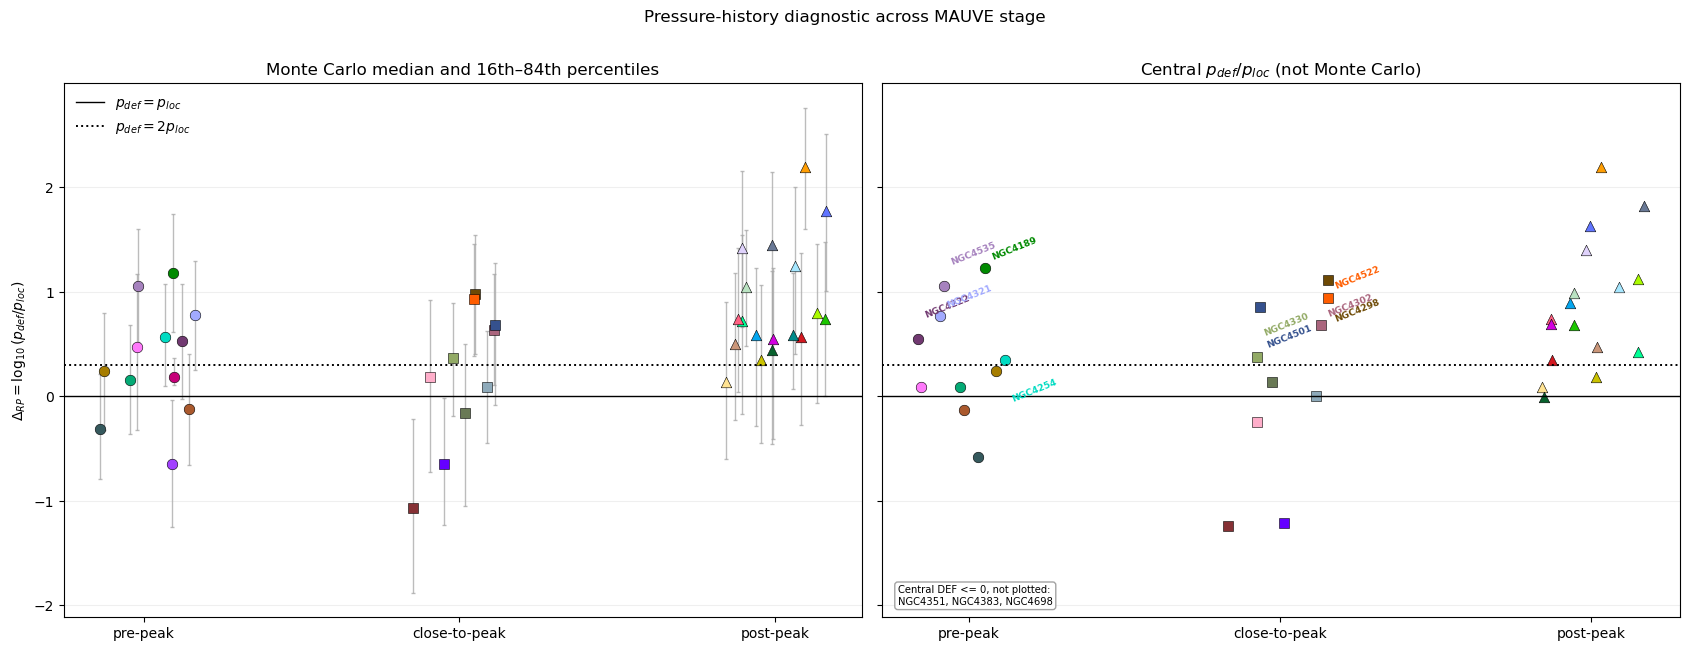

Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4222, NGC4254, NGC4321, NGC4535, NGC4298, NGC4302, NGC4330, NGC4501, NGC4522


In [12]:
fig, (ax_mc, ax_central) = plt.subplots(1, 2, figsize=(17.0, 6.4), sharey=True)
jitter_rng = np.random.default_rng(42)

for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & np.isfinite(results["Delta_RP_p50"])]
    x = stage + jitter_rng.uniform(-0.17, 0.17, len(group))
    y = group["Delta_RP_p50"].to_numpy()
    yerr = np.vstack([
        y - group["Delta_RP_p16"].to_numpy(),
        group["Delta_RP_p84"].to_numpy() - y,
    ])
    ax_mc.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.65", alpha=0.75,
                   elinewidth=1.0, capsize=1.5, zorder=1)
    for label_number, (xpos, (_, row)) in enumerate(zip(x, group.iterrows())):
        ax_mc.scatter(xpos, row["Delta_RP_p50"], s=58, color=row["galaxy_color"],
                      marker=stage_markers[stage], edgecolor="black", linewidth=0.4, zorder=2)

ax_mc.axhline(0.0, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_mc.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_mc.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_mc.set_ylabel(r"$\Delta_{RP}=\log_{10}(p_{def}/p_{loc})$")
ax_mc.set_title("Monte Carlo median and 16th–84th percentiles")
ax_mc.grid(axis="y", alpha=0.2)
ax_mc.legend(frameon=False)

# Added central-value stage panel. Negative/non-positive central deficiencies
# are deliberately absent because their stripping-radius inversion is undefined.
central_stage_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_jitter_rng = np.random.default_rng(43)
central_label_number = 0
for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & central_stage_valid]
    x = stage + central_jitter_rng.uniform(-0.17, 0.17, len(group))
    for xpos, (_, row) in zip(x, group.iterrows()):
        central_y = np.log10(row["pressure_ratio"])
        ax_central.scatter(
            xpos, central_y, s=58,
            color=row["galaxy_color"], marker=stage_markers[stage],
            edgecolor="black", linewidth=0.4,
        )
        if stage in (1, 2) and row["pressure_ratio"] > 2.0:
            label_offsets = [(4, 5), (4, 14), (4, -12)]
            offset = label_offsets[central_label_number % len(label_offsets)]
            ax_central.annotate(
                row["Galaxy"], (xpos, central_y), xytext=offset,
                textcoords="offset points", fontsize=6.6, fontweight="bold",
                color=row["galaxy_color"], rotation=22, ha="left",
                va="bottom" if offset[1] >= 0 else "top", zorder=3,
            )
            central_label_number += 1
ax_central.axhline(0.0, color="black", linewidth=1.0)
ax_central.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4)
ax_central.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_central.set_title("Central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_central.grid(axis="y", alpha=0.2)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_central.text(
    0.02, 0.02, "Central DEF <= 0, not plotted:\n" + ", ".join(negative_central_names),
    transform=ax_central.transAxes, ha="left", va="bottom", fontsize=7.2,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.6", "alpha": 0.9},
)
fig.suptitle("Pressure-history diagnostic across MAUVE stage", y=1.01)
fig.tight_layout()
plt.show()
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 12. Stage summaries and calibration sensitivity

Because the sample is modest and several uncertainties are shared systematics, the table reports robust descriptive summaries rather than a formal stage-sequence significance test. The second table asks how much the central deficiency changes if the AMIGA all-type fit is used instead of the fiducial morphology-dependent fit.

In [13]:
stage_summary = (
    results.groupby(["stage", "stage_label"], observed=True)
    .agg(
        N=("Galaxy", "size"),
        median_DEF=("DEF_p50", "median"),
        median_Delta_RP=("Delta_RP_p50", "median"),
        median_P_DEF_positive=("P_DEF_positive", "median"),
        median_P_past_given_positive=("P_past_given_DEF_positive", "median"),
        N_past_favoured=("MC_interpretation", lambda x: (x == "past-stripping favoured").sum()),
        N_ambiguous=("MC_interpretation", lambda x: (x == "ambiguous").sum()),
        N_ongoing_compatible=("MC_interpretation", lambda x: (x == "ongoing-compatible").sum()),
        N_mostly_nondeficient=("MC_interpretation", lambda x: (x == "mostly non-deficient / inversion unstable").sum()),
    )
    .reset_index()
)
display(stage_summary)

calibration_check = results[["Galaxy", "stage_label", "DEF", "DEF_all"]].copy()
calibration_check["DEF_all_minus_morph"] = calibration_check["DEF_all"] - calibration_check["DEF"]
display(calibration_check.sort_values("DEF_all_minus_morph", key=np.abs, ascending=False))
print("Median |DEF_all - DEF_morph| = "
      f"{np.median(np.abs(calibration_check['DEF_all_minus_morph'])):.3f} dex")

,stage,stage_label,N,median_DEF,median_Delta_RP,median_P_DEF_positive,median_P_past_given_positive,N_past_favoured,N_ambiguous,N_ongoing_compatible,N_mostly_nondeficient
0,1,pre-peak,12,0.3744,0.3547,0.9451,0.5196,2,7,2,1
1,2,close-to-peak,10,0.6414,0.2763,0.99,0.4989,2,6,2,0
2,3,post-peak,18,0.8798,0.7303,0.9974,0.712,6,11,0,1


,Galaxy,stage_label,DEF,DEF_all,DEF_all_minus_morph
27,NGC4405,post-peak,0.5491,1.099,0.55
6,NGC4351,pre-peak,-0.2297,0.3131,0.5428
7,NGC4383,pre-peak,-1.177,-0.6417,0.5356
35,NGC4580,post-peak,0.9486,1.466,0.5176
21,NGC4694,close-to-peak,0.05156,0.5583,0.5068
36,NGC4606,post-peak,1.248,1.723,0.4744
30,IC3392,post-peak,1.045,1.512,0.4672
31,NGC4457,post-peak,0.4793,0.932,0.4528
17,NGC4424,close-to-peak,0.5444,0.9863,0.442
22,NGC4064,post-peak,1.291,1.722,0.4312


Median |DEF_all - DEF_morph| = 0.127 dex


## 13. Automated QC and interpretation guardrails

These checks distinguish a notebook that merely ran from one whose key scientific joins and outputs are internally coherent.

- Every physical component must appear exactly once.
- All deterministic inputs must be finite and positive where required.
- A positive central DEF must produce a finite radius and pressure; a non-positive DEF must not.
- Monte Carlo probabilities must stay in $[0,1]$.
- The published $p_{\rm loc}$ regression must remain within its tolerance.
- Results must include all three MAUVE stages.

Passing these checks validates the implementation and bookkeeping. It does **not** remove the stated catalogue-provenance, calibration-applicability, projection, or model-systematic limitations.

In [14]:
expected_e_vrot_used = np.where(
    np.isfinite(results["e_vrot"]) & (results["e_vrot"] > 0),
    results["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * results["vrot"],
)
assert np.allclose(results["e_vrot_used"], expected_e_vrot_used, equal_nan=True)

assert len(results) == 40 and results["Galaxy"].nunique() == 40
assert set(results["stage"]) == {1, 2, 3}
assert results[["D25_kpc", "Ropt_kpc", "vrot", "Rproj_mpc", "p_loc"]].notna().all().all()
assert (results[["D25_kpc", "Ropt_kpc", "vrot", "p_loc"]] > 0).all().all()

positive_def = results["DEF"] > 0
assert results.loc[positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].notna().all().all()
assert results.loc[~positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].isna().all().all()

probability_columns = ["P_DEF_positive", "P_past_joint", "P_past_given_DEF_positive"]
for column in probability_columns:
    finite_probability = results[column].dropna()
    assert finite_probability.between(0.0, 1.0).all(), f"Invalid probability in {column}"

assert (results["P_past_joint"] <= results["P_DEF_positive"] + 1e-12).all()
assert np.median(np.abs(paper_ploc["fractional_residual"])) < 0.10

print("All automated QC checks passed.")
print(f"Central-input positive DEF: {positive_def.sum()}/40")
print("Monte Carlo interpretation counts:")
display(results["MC_interpretation"].value_counts().rename_axis("interpretation").to_frame("N"))

All automated QC checks passed.
Central-input positive DEF: 37/40
Monte Carlo interpretation counts:


,N
interpretation,
ambiguous,24
past-stripping favoured,10
ongoing-compatible,4
mostly non-deficient / inversion unstable,2


## 14. How to read and extend this notebook

### What is ready to use

- A complete 40-galaxy table with updated AMIGA expected H I masses.
- Deterministic $\mathrm{DEF}$, $r_{\rm strip}$, $p_{\rm def}$, $p_{\rm loc}$, $p_{\rm def}/p_{\rm loc}$, and $\Delta_{\rm RP}$.
- Monte Carlo intervals plus separate probabilities for having a physical positive deficiency and for exceeding the factor-of-two past-stripping threshold.
- Stage-level plots and summaries that do not feed the stage label back into the physical calculation.
- A regression check against published Köppen $p_{\rm loc}$ values.

### Limitations that must travel with any result

1. **Observed H I provenance:** `logMHI` is taken from the local MAUVE master compilation, whose per-row survey origin and uncertainty are not stored in the file. The 0.10 dex error is therefore a transparent provisional floor, not a reconstructed measurement likelihood.
2. **AMIGA applicability:** the isolated-galaxy diameter relation is used as the unperturbed baseline. Early-type objects—especially `NGC4694` with $T<0$—are extrapolation-sensitive.
3. **Projected radius:** $R_{\rm proj}$ is a lower limit to the three-dimensional cluster-centric radius. The constructed $p_{\rm loc}$ is intentionally optimistic.
4. **Rotation speeds:** literature `e_vrot` is used where available; the 1% fallback for missing errors is deliberately narrow and does not capture disturbed or non-circular kinematics.
5. **Shared systematics:** AMIGA coefficients, common distance, ICM model, and halo model induce correlated uncertainties. The current Monte Carlo treats the quoted scatters independently per galaxy and should not be used as a hierarchical population likelihood.
6. **Interpretation labels:** the 0.16/0.84 probability labels are reporting conventions introduced here. The physically primary outputs are the continuous ratio and probability columns.

### Recommended next steps

1. Build a row-level H I provenance table and replace the provisional common error with survey-specific uncertainties.
2. Compare HyperLeda $v_{\rm rot}$ with resolved VIVA/VERTICO kinematics and flag galaxies where the scalar velocity is unreliable.
3. Add the configuration-space $p_{\rm cfg}$ diagnostic as a separate layer.
4. Recompute the Monte Carlo with shared nuisance draws for the AMIGA coefficients and Virgo ICM/halo parameters before formal population inference.
5. Compare the pressure probabilities with direct resolved-H I truncation and tail morphology on a galaxy-by-galaxy basis.

In [15]:
# Compact ranked table for immediate follow-up. Sorting by the conditional past
# probability does not hide the separate probability of positive deficiency.
ranked = results[[
    "Galaxy", "stage_label", "DEF_p50", "P_DEF_positive",
    "ratio_p50", "P_past_given_DEF_positive", "P_past_joint",
    "MC_interpretation", "amiga_applicability_note",
]].sort_values(
    ["P_past_given_DEF_positive", "P_DEF_positive"],
    ascending=False,
    na_position="last",
)
display(ranked)

display(Markdown(
    "**Take-home rule:** use `ratio_p50` and its interval as the continuous diagnostic; "
    "read `P_past_given_DEF_positive` together with `P_DEF_positive`; and return to the "
    "provenance and applicability columns before making a claim about any individual galaxy."
))

,Galaxy,stage_label,DEF_p50,P_DEF_positive,ratio_p50,P_past_given_DEF_positive,P_past_joint,MC_interpretation,amiga_applicability_note
24,NGC4293,post-peak,2.053,1,156.2,0.9987,0.9987,past-stripping favoured,within adopted T-bin implementation
22,NGC4064,post-peak,1.361,1,59.24,0.9724,0.9724,past-stripping favoured,within adopted T-bin implementation
0,NGC4189,pre-peak,0.3786,0.9626,15.27,0.9372,0.9022,past-stripping favoured,within adopted T-bin implementation
35,NGC4580,post-peak,0.9544,0.9992,26.13,0.9267,0.926,past-stripping favoured,within adopted T-bin implementation
9,NGC4535,pre-peak,0.5608,0.9979,11.47,0.9169,0.915,past-stripping favoured,within adopted T-bin implementation
38,NGC4689,post-peak,0.8132,0.9969,11.25,0.9039,0.9011,past-stripping favoured,within adopted T-bin implementation
26,NGC4394,post-peak,0.5712,0.9263,28.18,0.9016,0.8351,past-stripping favoured,within adopted T-bin implementation
12,NGC4298,close-to-peak,0.5074,0.9882,9.572,0.8799,0.8696,past-stripping favoured,within adopted T-bin implementation
19,NGC4522,close-to-peak,0.9458,1,8.64,0.8743,0.8743,past-stripping favoured,within adopted T-bin implementation
29,NGC4450,post-peak,0.9964,0.9996,17.82,0.8709,0.8705,past-stripping favoured,within adopted T-bin implementation


**Take-home rule:** use `ratio_p50` and its interval as the continuous diagnostic; read `P_past_given_DEF_positive` together with `P_DEF_positive`; and return to the provenance and applicability columns before making a claim about any individual galaxy.